# Bank Marketing Dataset - Complete EDA & R3 Diagnostic
### Risk-Aware Dynamic Model Router (R3) - Benchmark Suite

This notebook performs a comprehensive EDA on the Bank Marketing dataset ($N = 45,211$, $d = 16$).
It covers:
1. **Data Audit & Imbalance Profiling** (Direct Marketing Telemarketing Calls)
2. **Continuous Variable Distribution & Skewness** (`duration`, `age`, `balance`)
3. **Categorical Association Analysis** (`job`, `education`, `contact`, `poutcome`)
4. **R3 Diagnostic Operating Window Computation** ($\Delta_{\text{Oracle}}$ & $\bar{\rho}_e$)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print('Fetching Bank Marketing dataset from OpenML...')
bank = fetch_openml(data_id=1461, as_frame=True, parser='auto')
df = bank.frame.copy()

# Rename columns for better readability and to match the plots
column_mapping = {
    'V1': 'age',
    'V2': 'job',
    'V3': 'marital',
    'V4': 'education',
    'V5': 'default',
    'V6': 'balance',
    'V7': 'housing',
    'V8': 'loan',
    'V9': 'contact',
    'V10': 'day',
    'V11': 'month',
    'V12': 'duration',
    'V13': 'campaign',
    'V14': 'pdays',
    'V15': 'previous',
    'V16': 'poutcome',
    'Class': 'y' # Assuming 'Class' is the target variable and should be 'y'
}
df.rename(columns=column_mapping, inplace=True)

print(f'Dataset Shape: {df.shape}')
display(df.head())

Fetching Bank Marketing dataset from OpenML...
Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


/tmp/ipykernel_2548/2137990580.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df.replace('unknown', np.nan, inplace=True)
/tmp/ipykernel_2548/2137990580.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[0], palette='magma')


--- Missing Values Summary ---
           Missing Count  Percentage (%)
poutcome           36959       81.747805
contact            13020       28.798301
education           1857        4.107407
job                  288        0.637013

--- Target Subscription Ratio (%) ---
y
1    88.30152
2    11.69848
Name: proportion, dtype: float64


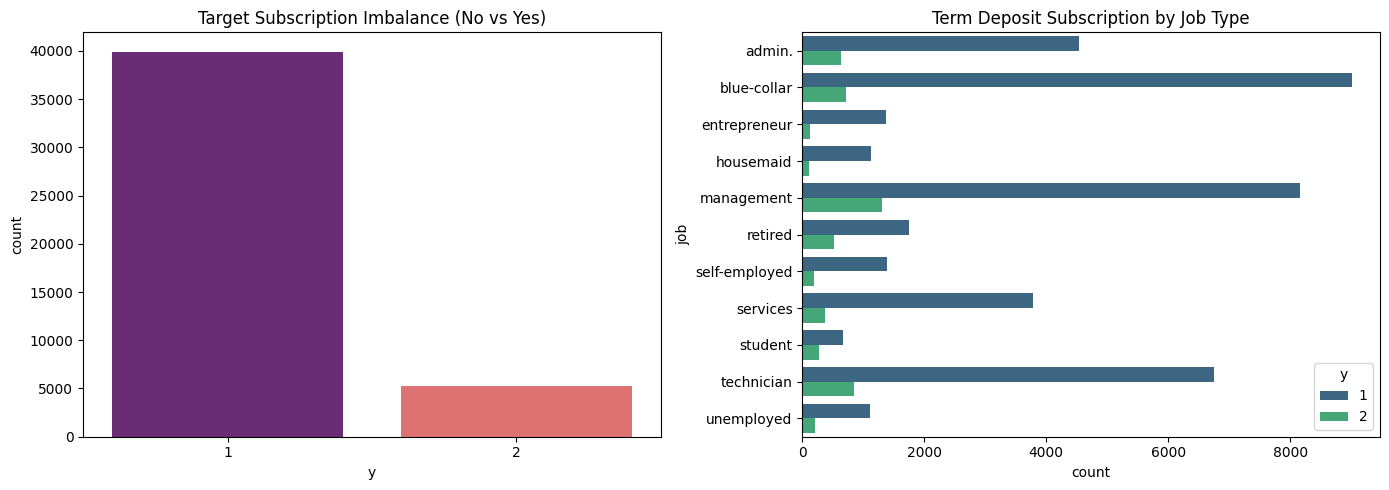

In [16]:
# --- 2. Data Audit & Missing Value Discovery ---
target_col = 'y'

# Check missing values and replace 'unknown' string placeholders
df.replace('unknown', np.nan, inplace=True)
df.replace('?', np.nan, inplace=True)

missing_summary = df.isnull().sum()
missing_pct = (missing_summary / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage (%)': missing_pct
}).query('`Missing Count` > 0').sort_values(by='Missing Count', ascending=False)

print('--- Missing Values Summary ---')
print(missing_df)

# Target Class Distribution
class_dist = df[target_col].value_counts(normalize=True) * 100
print('\n--- Target Subscription Ratio (%) ---') # Fixed SyntaxError
print(class_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x=target_col, ax=axes[0], palette='magma')
axes[0].set_title('Target Subscription Imbalance (No vs Yes)')

sns.countplot(data=df, y='job', hue=target_col, ax=axes[1], palette='viridis')
axes[1].set_title('Term Deposit Subscription by Job Type')
plt.tight_layout()
plt.show()

--- Continuous Features Descriptive Stats ---
            count         mean          std     min    25%    50%     75%  \
age       45211.0    40.936210    10.618762    18.0   33.0   39.0    48.0   
balance   45211.0  1362.272058  3044.765829 -8019.0   72.0  448.0  1428.0   
day       45211.0    15.806419     8.322476     1.0    8.0   16.0    21.0   
duration  45211.0   258.163080   257.527812     0.0  103.0  180.0   319.0   
campaign  45211.0     2.763841     3.098021     1.0    1.0    2.0     3.0   
pdays     45211.0    40.197828   100.128746    -1.0   -1.0   -1.0    -1.0   
previous  45211.0     0.580323     2.303441     0.0    0.0    0.0     0.0   

               max  
age           95.0  
balance   102127.0  
day           31.0  
duration    4918.0  
campaign      63.0  
pdays        871.0  
previous     275.0  


/tmp/ipykernel_2548/2895921699.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='duration', ax=axes[0], palette='Set2') # Changed x=target_col to x='y' for robustness


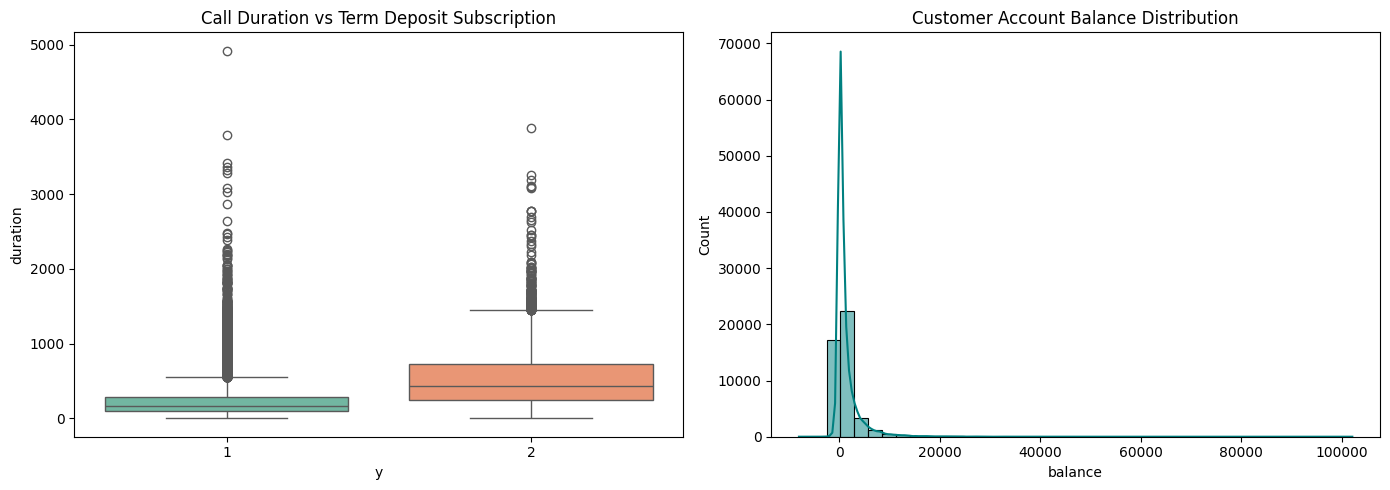

In [17]:
# --- 3. Continuous Feature Inspection & Skewness ---
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('--- Continuous Features Descriptive Stats ---')
print(df[num_cols].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Duration of call vs Subscription
sns.boxplot(data=df, x='y', y='duration', ax=axes[0], palette='Set2') # Changed x=target_col to x='y' for robustness
axes[0].set_title('Call Duration vs Term Deposit Subscription')

# Balance Distribution
sns.histplot(df['balance'], bins=40, ax=axes[1], color='teal', kde=True)
axes[1].set_title('Customer Account Balance Distribution')
plt.tight_layout()
plt.show()

In [18]:
# --- 4. R3 Diagnostic Operating Window Computation ---
target_col = 'y' # Explicitly ensure target_col is 'y'
X = df.drop(columns=[target_col])
# Correcting the target variable assignment: '2' maps to 1 (subscribed), '1' maps to 0 (not subscribed)
y = (df[target_col] == '2').astype(int).values

# Preprocessing setup
num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object', 'category']).columns

num_tf = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_tf = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_tf, num_features), ('cat', cat_tf, cat_features)])

X_proc = preprocessor.fit_transform(X)

# 5-Fold Stratified Split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LR': LogisticRegression(max_iter=1000),
    'XGB': HistGradientBoostingClassifier(),
    'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300, random_state=42)
}

oof_probs = {m: np.zeros((len(y), 2)) for m in models}

for train_idx, val_idx in skf.split(X_proc, y):
    X_tr, X_val = X_proc[train_idx], X_proc[val_idx]
    y_tr = y[train_idx]
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        oof_probs[name][val_idx] = model.predict_proba(X_val)

# Vector Failure Computation
accs, failures = {}, {}
for name in models:
    preds = np.argmax(oof_probs[name], axis=1)
    accs[name] = accuracy_score(y, preds)
    failures[name] = (preds != y).astype(int)

# Oracle Headroom (Delta_Oracle)
oracle_correct = np.any([failures[m] == 0 for m in models], axis=0)
acc_oracle = np.mean(oracle_correct)
best_static_acc = max(accs.values())
delta_oracle = acc_oracle - best_static_acc

# Pairwise Error Correlation (rho_e)
rho_list = []
keys = list(models.keys())
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        r_i, r_j = failures[keys[i]], failures[keys[j]]
        rho_list.append(np.corrcoef(r_i, r_j)[0, 1])
avg_rho = np.mean(rho_list)

print('==================================================')
print('   BANK MARKETING DATASET - R3 DIAGNOSTIC EVAL    ')
print('==================================================')
for m in models:
    print(f'Base Model Accuracy [{m}]: {accs[m]*100:.2f}%')
print(f'Best Static Model Acc     : {best_static_acc*100:.2f}%')
print(f'Oracle Upper Bound Acc    : {acc_oracle*100:.2f}%')
print(f'Oracle Headroom (Delta)   : {delta_oracle*100:.2f}%')
print(f'Pairwise Error Corr (rho) : {avg_rho:.3f}')
print('--------------------------------------------------')
if delta_oracle >= 0.03 and avg_rho <= 0.45:
    print('STATUS: PASS -> Bank Marketing dataset is OPTIMAL for R3 Dynamic Routing')
else:
    print('STATUS: FAIL -> Static ensemble recommended')
print('==================================================')

   BANK MARKETING DATASET - R3 DIAGNOSTIC EVAL    
Base Model Accuracy [LR]: 90.09%
Base Model Accuracy [XGB]: 90.77%
Base Model Accuracy [MLP]: 89.98%
Best Static Model Acc     : 90.77%
Oracle Upper Bound Acc    : 94.38%
Oracle Headroom (Delta)   : 3.61%
Pairwise Error Corr (rho) : 0.677
--------------------------------------------------
STATUS: FAIL -> Static ensemble recommended
